# CSC 405 Final Project  
## Dirty Iranian Transactions Dataset

This notebook analyzes transaction data and focuses on predicting whether a transaction will succeed or fail.

In [27]:
import pandas as pd
import numpy as np

In [28]:
df = pd.read_csv("../data/trx-10k.csv")
df.head()

,status,time,card_type,city,amount,id
0,success,2025-09-07 10:48:00,Visa,Tehran,1427657.0,98
1,success,2025-09-20 13:10:00,MastCard,Tehran,1578078.0,52
2,fail,2025-09-29 03:27:00,Visa,Tehran,250000.0,20
3,success,2025-09-15 13:13:00,Discover,Isfahan,0.0,40
4,success,2025-09-11 11:11:00,Visa,Tehran,1782689.0,59


# Part 1: Data Cleaning

The dataset has inconsistent values in the status column, so we clean them before analysis.

In [30]:
df["status"] = df["status"].str.lower()

df["status"] = df["status"].replace({
    "failed": "fail",
    "succeed": "success"
})

df["status"].value_counts()

status
fail       5366
success    4634
Name: count, dtype: int64

# Part 2: Exploratory Data Analysis (EDA)

Next, we explore the dataset using summary statistics and transaction patterns.

In [31]:
df.describe()

,amount,id
count,1.000000e+04,10000.000000
mean,2.954735e+08,50.061200
std,1.692035e+09,28.870875
min,-9.999990e+05,1.000000
25%,1.005000e+02,25.000000
50%,3.436790e+05,50.000000
75%,9.144650e+05,74.000000
max,1.000000e+10,100.000000


In [32]:
df["city"].value_counts().head(10)

city
Tehran     2063
Tabriz     1368
Isfahan    1073
Mashhad     900
Shiraz      727
Qom         669
Karaj       642
Ahvaz       632
THR         409
TEHRAN      403
Name: count, dtype: int64

# Part 3: Visualization

The charts below help show important patterns in the transaction data.

In [33]:
import matplotlib.pyplot as plt

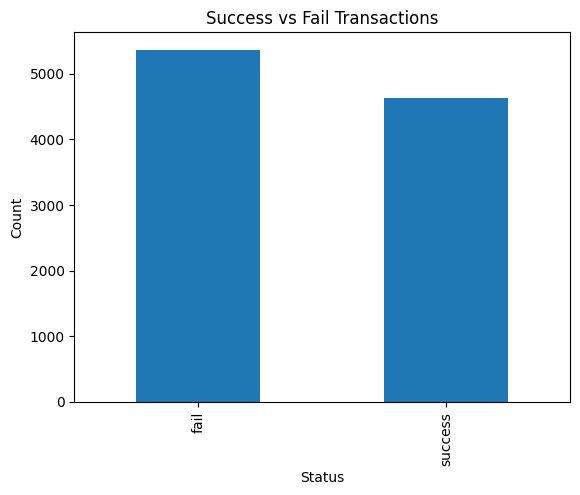

In [34]:
df["status"].value_counts().plot(kind="bar")
plt.title("Success vs Fail Transactions")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

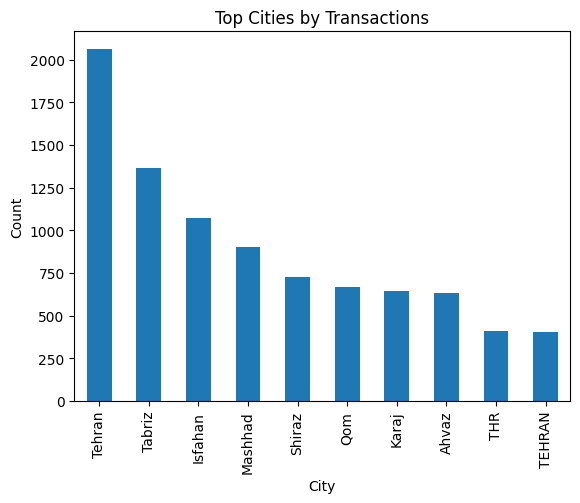

In [35]:
df["city"].value_counts().head(10).plot(kind="bar")
plt.title("Top Cities by Transactions")
plt.xlabel("City")
plt.ylabel("Count")
plt.show()

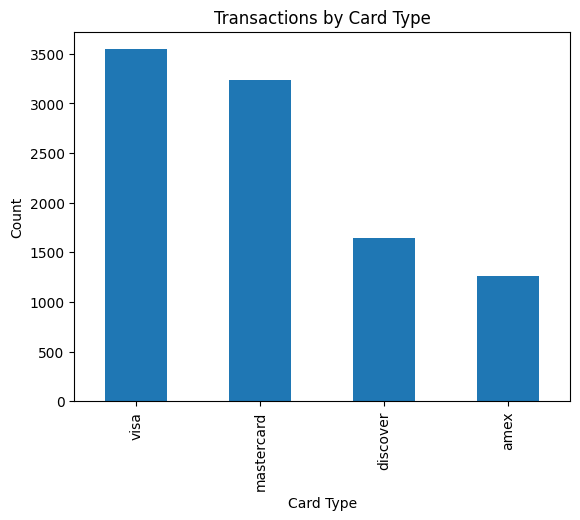

In [55]:
df["card_type"].value_counts().plot(kind="bar")
plt.title("Transactions by Card Type")
plt.xlabel("Card Type")
plt.ylabel("Count")
plt.show()

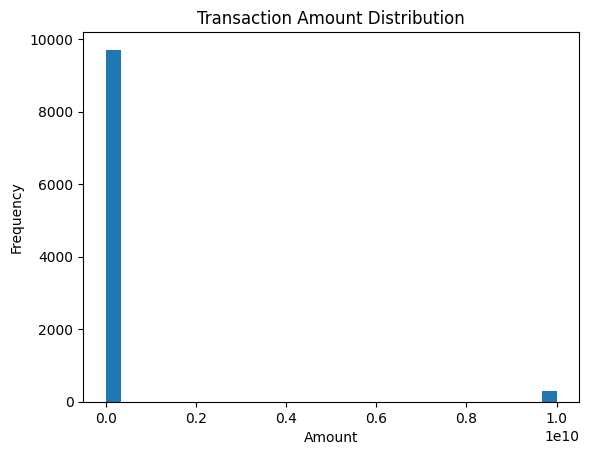

In [56]:
df["amount"].plot(kind="hist", bins=30)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

# Part 4: Statistical Analysis

We compare the average transaction amount for successful and failed transactions.

In [36]:
success_amt = df[df["status"] == "success"]["amount"]
fail_amt = df[df["status"] == "fail"]["amount"]

print("Average Success Amount:", success_amt.mean())
print("Average Fail Amount:", fail_amt.mean())

Average Success Amount: 233535316.81063876
Average Fail Amount: 348962343.9617033


**Null Hypothesis:** The average transaction amount is the same for successful and failed transactions.

The average failed transaction amount was higher than the average successful transaction amount. This suggests transaction amount may be related to whether a payment succeeds or fails.

# Part 5: Data Modeling

We build machine learning models to predict whether a transaction will succeed or fail.
We compare a baseline model and a more advanced model.

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [46]:
# Clean feature columns before modeling
df["city"] = df["city"].str.lower().str.strip()
df["card_type"] = df["card_type"].str.lower().str.strip()

df["city"] = df["city"].replace({
    "tehr@n": "tehran",
    "thr": "tehran",
    "thran": "tehran",
    "tehran ": "tehran"
})

df["card_type"] = df["card_type"].replace({
    "mastcard": "mastercard",
    "master card": "mastercard",
    "master-card": "mastercard",
    "vsa": "visa"
})

In [47]:
df["time"] = pd.to_datetime(df["time"])
df["hour"] = df["time"].dt.hour

In [48]:
X = df[["card_type", "city", "amount", "hour"]]
y = df["status"]

X = pd.get_dummies(X, drop_first=True)

le = LabelEncoder()
y = le.fit_transform(y)

X.head()

,amount,hour,card_type_discover,card_type_mastercard,card_type_visa,city_isfahan,city_karaj,city_mashhad,city_qom,city_shiraz,city_tabriz,city_tehran
0,1427657.0,10,False,False,True,False,False,False,False,False,False,True
1,1578078.0,13,False,True,False,False,False,False,False,False,False,True
2,250000.0,3,False,False,True,False,False,False,False,False,False,True
3,0.0,13,True,False,False,True,False,False,False,False,False,False
4,1782689.0,11,False,False,True,False,False,False,False,False,False,True


In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 8000
Testing rows: 2000


In [50]:
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)
tree_accuracy = accuracy_score(y_test, tree_predictions)

print("Decision Tree Accuracy:", tree_accuracy)

Decision Tree Accuracy: 0.508


In [51]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.498


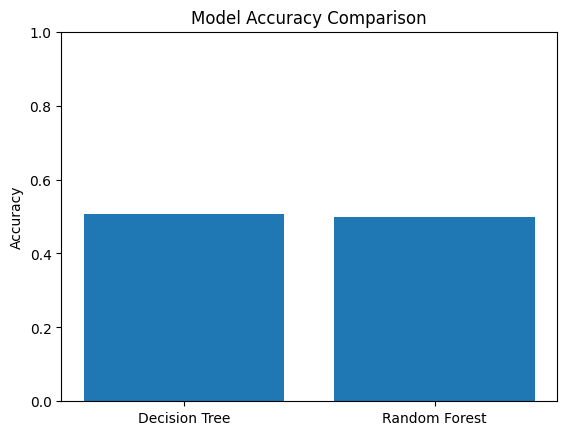

In [52]:
models = ["Decision Tree", "Random Forest"]
scores = [tree_accuracy, rf_accuracy]

plt.bar(models, scores)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

The models were improved by cleaning city and card type values and adding transaction hour as a feature.

The model accuracy stayed close to 50%, which shows that the current dataset features are not strong enough by themselves to predict whether a transaction succeeds or fails. This is still useful because it shows that more information would be needed to build a stronger prediction model.

Even though the accuracy was low, the modeling process still helped identify that the current features are limited for prediction. Future models may improve with more transaction details or historical behavior data.

# Model Comparison

The Decision Tree model performed slightly better than the Random Forest model on this dataset.

Both models had accuracy near 50%, which suggests the available features (amount, city, card type, and hour) are not strong enough alone to predict transaction outcomes very well.

# Final Conclusion

This project analyzed the Dirty Iranian Transactions Dataset using the full data science process.

We cleaned inconsistent data, explored patterns, created visualizations, compared transaction amounts, and built predictive models.

The results showed that failed transactions had a higher average amount than successful transactions. The machine learning models had limited accuracy, which suggests that more features would be needed for stronger predictions.

Overall, this project demonstrates how data science can be used to clean messy data, discover patterns, and test predictive methods.